<a href="https://colab.research.google.com/github/stefaniamartinezr/Anal-tica-de-Negocios/blob/main/Presentaci%C3%B3nFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Contexto

La base de datos utilizada contiene información de delitos registrados en Colombia durante el año 2025. Esta información es importante para la toma de decisiones porque permite identificar patrones delictivos, niveles de gravedad y características relacionadas con los diferentes casos registrados. A partir de estos datos, organizaciones como la Policía Nacional o entidades encargadas de seguridad y prevención pueden fortalecer estrategias de control, optimizar la asignación de recursos y mejorar los procesos de prevención y seguridad ciudadana.

El uso de modelos de analítica de negocios y machine learning beneficia a la organización porque facilita el análisis de grandes volúmenes de información y permite encontrar relaciones entre variables que no son fáciles de identificar manualmente. Además, ayuda a realizar clasificaciones, agrupamientos y segmentaciones útiles para apoyar decisiones basadas en datos.

Para este análisis se utilizó una nueva base de datos procesada con variables relacionadas con niveles de gravedad. Las variables seleccionadas fueron:

* **MES:** indica el mes en el que ocurrió el registro, permitiendo identificar variaciones temporales.
* **DELITOS_GRAVEDAD:** representa el nivel o clasificación de gravedad del delito.
* **AGRUPACION_GRAVEDAD:** clasifica la gravedad según el grupo poblacional o categoría analizada.
* **DEPARTAMENTO_GRAVEDAD:** identifica el nivel de gravedad según el departamento donde ocurrió el caso.
* **ARMAS_MEDIOS_GRAVEDAD:** corresponde a la clasificación relacionada con el arma o medio utilizado y funciona como variable objetivo en el modelo de clasificación.


## Modelo 1: Árbol de decisión

El modelo de árbol de decisión se utilizó para clasificar la variable ARMAS_MEDIOS_GRAVEDAD a partir de las demás variables seleccionadas. Este modelo permite identificar qué factores tienen mayor influencia sobre los resultados y facilita la interpretación mediante reglas de decisión.

Para adaptar el modelo al formato trabajado en clase, la variable ARMAS_MEDIOS_GRAVEDAD se reorganizó en dos categorías binarias, permitiendo facilitar el proceso de clasificación y el análisis de resultados. Esta transformación permitió que el árbol de decisión trabajara con una clasificación binaria y que la matriz de confusión tuviera una estructura 2x2, facilitando el cálculo de métricas como exactitud, sensibilidad, especificidad y precisión.

En este sentido, el modelo no busca identificar cada nivel de gravedad de manera individual, sino determinar si, según variables como MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD y DEPARTAMENTO_GRAVEDAD, el registro pertenece a una categoría de mayor gravedad o a otra clasificación diferente.

Este modelo es importante para una empresa u organización porque ayuda a:

* Identificar patrones de comportamiento.
* Detectar variables con mayor influencia.
* Realizar clasificaciones automáticas.
* Apoyar la toma de decisiones estratégicas.

En este caso, el modelo permite analizar cómo variables como el departamento, la gravedad del delito, la agrupación poblacional y el mes influyen en la clasificación relacionada con armas o medios utilizados.

El código mostró una exactitud aproximada del 85.48%, lo que indica que el modelo logró clasificar correctamente la mayoría de los registros analizados. Además, las métricas obtenidas muestran que el modelo tiene una alta capacidad para identificar correctamente los casos positivos.



## Modelo 2: K-Means

Posteriormente, se implementó un modelo de agrupamiento K-Means con el objetivo de identificar grupos de registros con características similares dentro de la base de datos.

En el modelo se trabajó con 5 clusters:

K = 5

Este modelo es importante porque permite segmentar la información automáticamente y encontrar patrones ocultos dentro de los datos.

La aplicación de K-Means beneficia a una organización porque permite:

* Identificar grupos con características similares.
* Detectar zonas o perfiles de mayor riesgo.
* Segmentar poblaciones o comportamientos.
* Diseñar estrategias específicas para cada grupo encontrado.

Según los resultados obtenidos en el código, el modelo logró formar agrupamientos diferenciados entre los registros, evidenciando similitudes entre variables relacionadas con gravedad, departamento y tipo de delito. Esto demuestra que la base de datos contiene patrones que pueden utilizarse para mejorar el análisis y la toma de decisiones.



0. Librerias de trabajo

In [ ]:
# 0. Se procede con la carga de las librerías de trabajo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

1. Carga de datos

In [ ]:
# 1. se procede con la carga de los datos de trabajo

#nxl = '/content/Policia Nacional C Informe 2025.xlsx'
nxl = '/content/BaseDatosExpulgada.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)
XDB=XDB.dropna()
# Define un diccionario para mapear cada delito a un valor de gravedad (1-11)
# Por favor, ajusta los valores numéricos según tu criterio.
delitos_gravedad_map = {
    'ARTÍCULO 111. LESIONES PERSONALES': 3, # Ejemplo: Ajusta este valor
    'ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR': 5, # Ejemplo: Ajusta este valor
    'ARTÍCULO 205. ACCESO CARNAL VIOLENTO': 9, # Ejemplo: Ajusta este valor
    'ARTÍCULO 206. ACTO SEXUAL VIOLENTO': 8, # Ejemplo: Ajusta este valor
    'ARTÍCULO 208. ACCESO CARNAL ABUSIVO CON MENOR DE 14 AÑOS': 10, # Ejemplo: Ajusta este valor
    'ARTÍCULO 103. HOMICIDIO': 11, # Ejemplo: Ajusta este valor
    'ARTÍCULO 104A. FEMINICIDIO': 11, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO PERSONAS': 4, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO RESIDENCIAS': 6, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO PIRATERIA TERRESTRE': 7, # Ejemplo: Ajusta este valor
    'ARTÍCULO 243. ABIGEATO': 2, # Ejemplo: Ajusta este valor
    'ARTÍCULO 168. SECUESTRO SIMPLE': 9, # Ejemplo: Ajusta este valor
    'ARTÍCULO 169. SECUESTRO EXTORSIVO': 10, # Ejemplo: Ajusta este valor
    'ARTÍCULO 347. AMENAZAS': 1, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO MOTOCICLETAS': 4, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO AUTOMOTORES': 5  # Ejemplo: Ajusta este valor
}

# Crea una nueva columna 'DELITOS_GRAVEDAD' mapeando los valores existentes
XDB['DELITOS_GRAVEDAD'] = XDB['DELITOS'].map(delitos_gravedad_map)

# Muestra las primeras filas del DataFrame con la nueva columna
#display(XDB[['DELITOS', 'DELITOS_GRAVEDAD']].head())

# Mapeo para 'ARMAS MEDIOS'
print("Valores únicos en 'ARMAS MEDIOS':", XDB['ARMAS MEDIOS'].unique())
armas_medios_gravedad_map = {
    'ARMA DE FUEGO': 1, # Ajusta este valor
    'ARMA TRAUMATICA': 0, # Ajusta este valor
    'ACIDO': 1, # Ajusta este valor
}
XDB['ARMAS_MEDIOS_GRAVEDAD'] = XDB['ARMAS MEDIOS'].map(armas_medios_gravedad_map)
#display(XDB[['ARMAS MEDIOS', 'ARMAS_MEDIOS_GRAVEDAD']].head())

# Mapeo para 'GENERO'
print("Valores únicos en 'GENERO':", XDB['GENERO'].unique())
genero_gravedad_map = {
    'MASCULINO': 1, # Ajusta este valor
    'FEMENINO': 1, # Ajusta este valor
    'LGBTI': 1 # Ajusta este valor
}
XDB['GENERO_GRAVEDAD'] = XDB['GENERO'].map(genero_gravedad_map)
#display(XDB[['GENERO', 'GENERO_GRAVEDAD']].head())

# Mapeo para 'AGRUPACION'
print("Valores únicos en 'AGRUPACION':", XDB['AGRUPACION'].unique())
agrupacion_gravedad_map = {
    'ADULTOS': 3, # Ajusta este valor
    'ADOLESCENTES': 2, # Ajusta este valor
    'MENORES': 1 # Ajusta este valor
}
XDB['AGRUPACION_GRAVEDAD'] = XDB['AGRUPACION'].map(agrupacion_gravedad_map)
#display(XDB[['AGRUPACION', 'AGRUPACION_GRAVEDAD']].head())

# Mapeo para 'DEPARTAMENTO'
print("Valores únicos en 'DEPARTAMENTO':", XDB['DEPARTAMENTO'].unique())
departamento_gravedad_map = {
    'RISARALDA': 2, # Ajusta este valor
    'BOGOTA': 5, # Ajusta este valor
    'ANTIOQUIA': 4, # Ajusta este valor
    'CAUCA': 7, # Ajusta este valor
    'VALLE': 6, # Ajusta este valor
    'SANTANDER': 1, # Ajusta este valor
    'ATLÁNTICO': 4, # Ajusta este valor
    'CUNDINAMARCA': 3 # Ajusta este valor
}
XDB['DEPARTAMENTO_GRAVEDAD'] = XDB['DEPARTAMENTO'].map(departamento_gravedad_map)
#display(XDB[['DEPARTAMENTO', 'DEPARTAMENTO_GRAVEDAD']].head())
XDB = XDB.dropna()

# Variables de entrada:
# DEPARTAMENTO, GENERO, AGRUPACION
XD = XDB.iloc[:, [5,7,10,11]]

# Variable de salida:
# ARMAS MEDIOS
yd = XDB.iloc[:, 8]

XDB.to_excel('Procesamiento.xlsx')
display(XD)
display(yd)

Valores únicos en 'ARMAS MEDIOS': ['ARMA TRAUMATICA' 'ACIDO' 'ARMA DE FUEGO']
Valores únicos en 'GENERO': ['FEMENINO' 'MASCULINO']
Valores únicos en 'AGRUPACION': ['ADULTOS' 'ADOLESCENTES' 'MENORES']
Valores únicos en 'DEPARTAMENTO': ['ANTIOQUIA' 'ATLÁNTICO' 'SANTANDER' 'VALLE' 'RISARALDA' 'BOGOTA' 'CAUCA'
 'CUNDINAMARCA']


,MES,DELITOS_GRAVEDAD,AGRUPACION_GRAVEDAD,DEPARTAMENTO_GRAVEDAD
0,1,3,3,4
1,1,3,2,4
2,1,3,3,4
3,1,3,3,4
4,1,3,3,1
...,...,...,...,...
422,2,3,3,2
423,2,3,3,2
424,2,3,3,2
425,2,3,3,6


,ARMAS_MEDIOS_GRAVEDAD
0,0
1,0
2,0
3,0
4,0
...,...
422,1
423,1
424,1
425,1


2. Se procede con la implementación del modelo del árbol

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Se crea y entrena el modelo
mar = DecisionTreeClassifier(criterion='gini', max_depth=4)
mar.fit(XD, yd)     # Aqui el modelo busca relación entrada-salida
np.sum(yd)
# ¿Y qué fue lo que hizo el modelo?
ydp = mar.predict(XD)     # Esto es lo que pronostica el modelo

# Se construye la matriz de confusión
cm = confusion_matrix(yd, ydp)
display(cm)

# Métricas de Desempeño
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

Ex = (VP + VN) / len(XD)     # Exactitud: comportamiento general
print("La exactitud es:", Ex)

Sen = VP / (VP + FN)          # Sensibilidad
print("La sensibilidad es:", Sen)

Spe = VN / (VN + FP)          # Especificidad
print("La especificidad es:", Spe)

Pre = VP / (VP + FP)          # Precisión
print("La Precisión es:", Pre)

PreNeg = VN / (VN + FN)       # Predicción negativa
print("La Predicción Negativa es:", PreNeg)

array([[179,  20],
       [ 15, 213]])

La exactitud es: 0.9180327868852459
La sensibilidad es: 0.9342105263157895
La especificidad es: 0.8994974874371859
La Precisión es: 0.9141630901287554
La Predicción Negativa es: 0.9226804123711341


Para adaptar el modelo al formato trabajado en clase, la variable de salida **ARMAS_MEDIOS_GRAVEDAD** se reorganizó en dos categorías binarias, permitiendo facilitar el proceso de clasificación y el análisis de resultados. De esta manera, una categoría representa los registros asociados a mayores niveles de gravedad y la otra agrupa los registros restantes dentro de la clasificación establecida en la base de datos procesada.

Esta transformación permitió que el árbol de decisión trabajara con una clasificación binaria y que la matriz de confusión tuviera una estructura 2x2, facilitando el cálculo de métricas como exactitud, sensibilidad, especificidad y precisión.

En este sentido, el modelo no busca identificar cada nivel de gravedad de manera individual, sino determinar si, según variables como MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD y DEPARTAMENTO_GRAVEDAD, el registro pertenece a una categoría de mayor gravedad o a otra clasificación diferente. Esto hace que el análisis sea más claro para la toma de decisiones, porque permite identificar patrones generales relacionados con los niveles de gravedad presentes en los registros analizados.

3. Despliegue del Àrbol de decisión

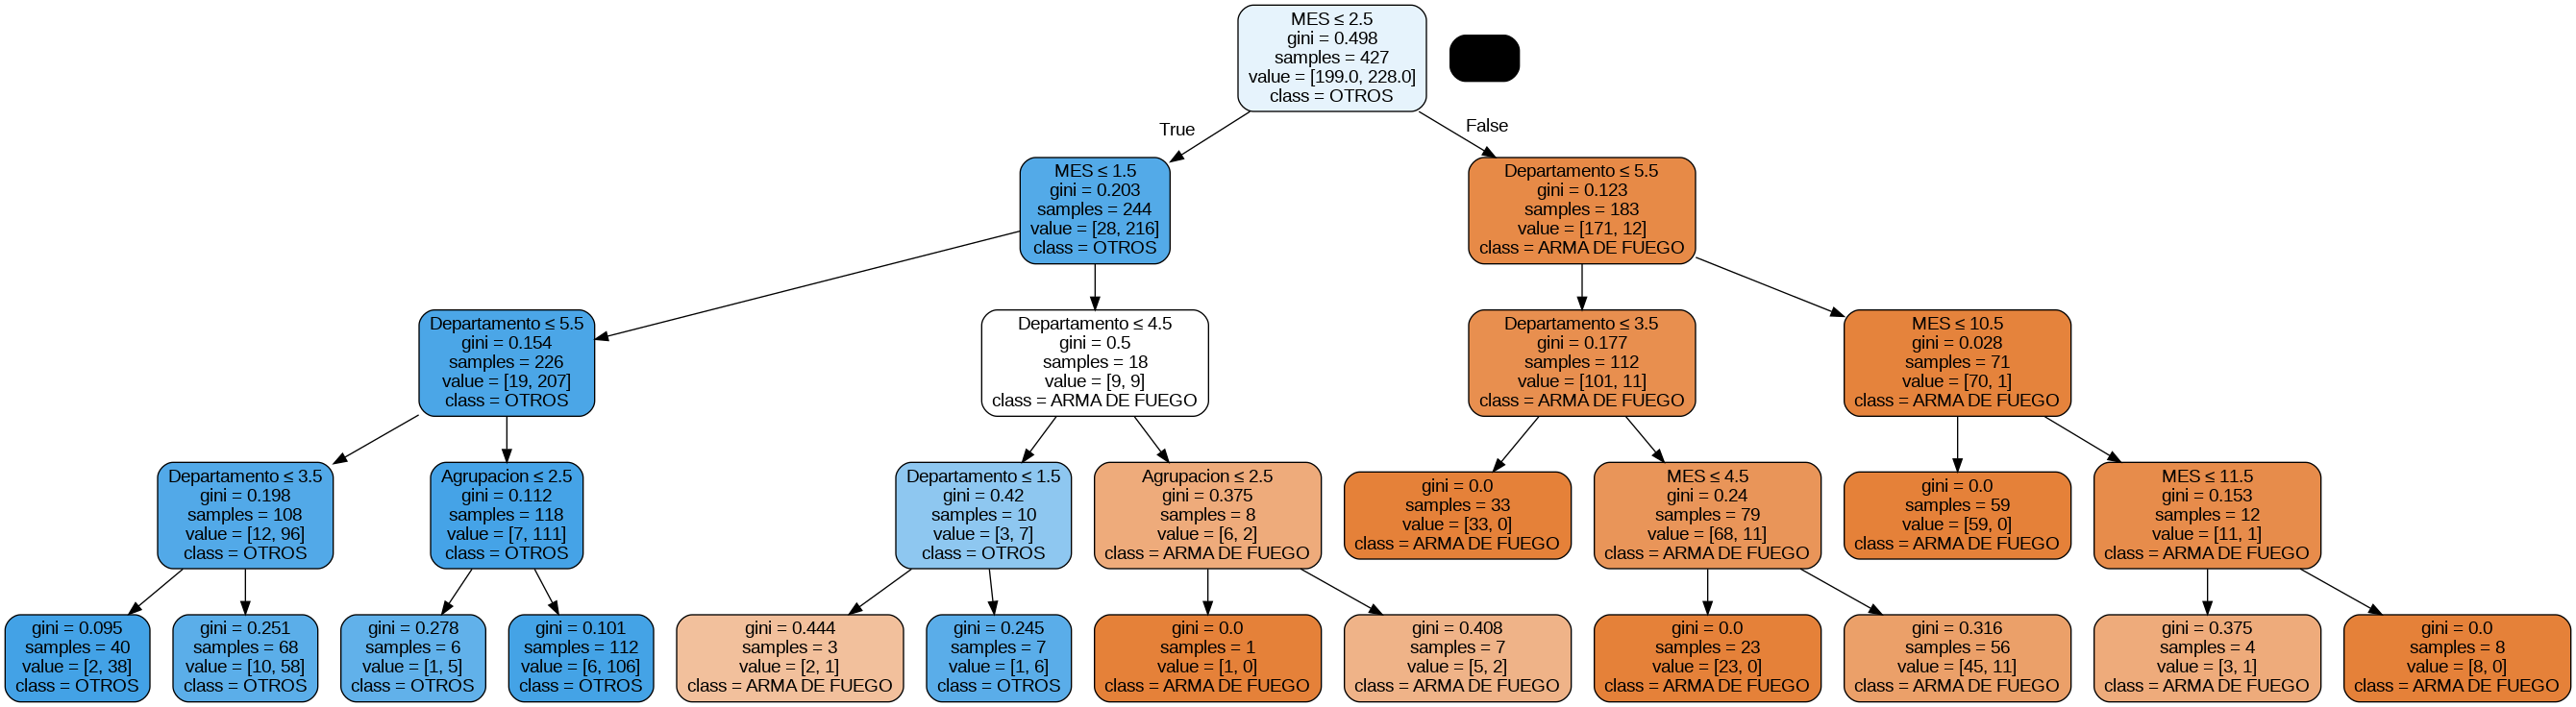

In [ ]:
# 3. Despliegue del Árbol de Decisión

from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image

vs = ["MES", "delitos","Agrupacion","Departamento"]     # Títulos del árbol
clases = ["ARMA DE FUEGO", "OTROS"]              # Categorías de salida

dot_data = export_graphviz(
    mar,
    feature_names = vs,
    class_names = clases,
    filled = True,
    rounded = True,
    special_characters = True
)

graph = graph_from_dot_data(dot_data)
graph.write_png('Arbol.png')

Image('Arbol.png')

In [ ]:
# Para detectar cual fue el departamento con mayor uso de ARMA DE FUEGO

arma_fuego = XDB[XDB.iloc[:,0] == 'ARMA DE FUEGO']#filtro del arma de fuego

# Contar cuántos casos de arma de fuego hay por departamento
conteo_departamento = arma_fuego.iloc[:,1].value_counts()

display(conteo_departamento)

# Mostrar el departamento con mayor cantidad de casos
departamento_mayor = conteo_departamento.idxmax()
cantidad_mayor = conteo_departamento.max()

print("El departamento con mayor uso de arma de fuego es:", departamento_mayor)
print("Cantidad de casos:", cantidad_mayor)

,count
DEPARTAMENTO,
VALLE,95
ATLÁNTICO,38
RISARALDA,23
SANTANDER,17
ANTIOQUIA,17
CAUCA,17
BOGOTA,6
CUNDINAMARCA,1


El departamento con mayor uso de arma de fuego es: VALLE
Cantidad de casos: 95


**Analisis de arbol de decisión**

El árbol de decisión se construyó con el objetivo de clasificar la variable ARMAS_MEDIOS_GRAVEDAD utilizando como variables de entrada MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD y DEPARTAMENTO_GRAVEDAD. La variable de salida se reorganizó en dos categorías binarias para facilitar la clasificación y permitir trabajar con una matriz de confusión 2x2.

El árbol muestra que variables como DEPARTAMENTO_GRAVEDAD y DELITOS_GRAVEDAD tienen un peso importante en la clasificación, ya que aparecen en varios nodos de división. Esto indica que la ubicación geográfica y el nivel de gravedad ayudan al modelo a diferenciar los registros.

Además, la mayoría de registros quedaron asociados a una misma categoría predominante, mostrando que existen patrones marcados dentro de la base de datos analizada.

En este árbol, los valores de Gini son bajos en varios nodos, lo que indica que las divisiones realizadas por el modelo presentan una buena separación entre categorías. En general, el modelo confirma que existen patrones importantes relacionados con gravedad, ubicación y agrupación poblacional dentro de los registros analizados.


4. Arbol

In [ ]:

from sklearn.tree import export_text

# Nombres de las variables de entrada del modelo
vs = ["MES", "delitos","Agrupacion","Departamento"]

# Mostrar las reglas del árbol
tree_rules = export_text(mar, feature_names=vs)

print("Reglas del árbol de decisión:\n")
print(tree_rules)

Reglas del árbol de decisión:

|--- MES <= 2.50
|   |--- MES <= 1.50
|   |   |--- Departamento <= 5.50
|   |   |   |--- Departamento <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- Departamento >  3.50
|   |   |   |   |--- class: 1
|   |   |--- Departamento >  5.50
|   |   |   |--- Agrupacion <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- Agrupacion >  2.50
|   |   |   |   |--- class: 1
|   |--- MES >  1.50
|   |   |--- Departamento <= 4.50
|   |   |   |--- Departamento <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- Departamento >  1.50
|   |   |   |   |--- class: 1
|   |   |--- Departamento >  4.50
|   |   |   |--- Agrupacion <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- Agrupacion >  2.50
|   |   |   |   |--- class: 0
|--- MES >  2.50
|   |--- Departamento <= 5.50
|   |   |--- Departamento <= 3.50
|   |   |   |--- class: 0
|   |   |--- Departamento >  3.50
|   |   |   |--- MES <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- MES >  4.50
|   |   |

5. Se realiza la predicción con el modelo entrenado


In [ ]:
prediccion_armas = mar.predict(XD)

# Se convierte la predicción numérica a texto
#prediccion_armas_texto = le4.inverse_transform(prediccion_armas)

XDB["Prediccion_Arma"] = prediccion_armas

XDB = XDB.dropna(how='all')

display(XDB)

,ARMAS MEDIOS,DEPARTAMENTO,GENERO,AGRUPACION,DELITOS,MES,CANTIDAD,DELITOS_GRAVEDAD,ARMAS_MEDIOS_GRAVEDAD,GENERO_GRAVEDAD,AGRUPACION_GRAVEDAD,DEPARTAMENTO_GRAVEDAD,Prediccion_Arma
0,ARMA TRAUMATICA,ANTIOQUIA,FEMENINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,1,1,3,0,1,3,4,1
1,ARMA TRAUMATICA,ATLÁNTICO,MASCULINO,ADOLESCENTES,ARTÍCULO 111. LESIONES PERSONALES,1,1,3,0,1,2,4,1
2,ARMA TRAUMATICA,ANTIOQUIA,MASCULINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,1,1,3,0,1,3,4,1
3,ARMA TRAUMATICA,ANTIOQUIA,MASCULINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,1,1,3,0,1,3,4,1
4,ARMA TRAUMATICA,SANTANDER,MASCULINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,1,1,3,0,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,ARMA DE FUEGO,RISARALDA,FEMENINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,2,1,3,1,1,3,2,1
423,ARMA DE FUEGO,RISARALDA,FEMENINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,2,1,3,1,1,3,2,1
424,ARMA DE FUEGO,RISARALDA,MASCULINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,2,1,3,1,1,3,2,1
425,ARMA DE FUEGO,VALLE,MASCULINO,ADULTOS,ARTÍCULO 111. LESIONES PERSONALES,2,1,3,1,1,3,6,0


#Modelo 2: K-means



0. Se procede con la carga de las librerías de trabajo


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

1. Se cargan los datos de trabajo


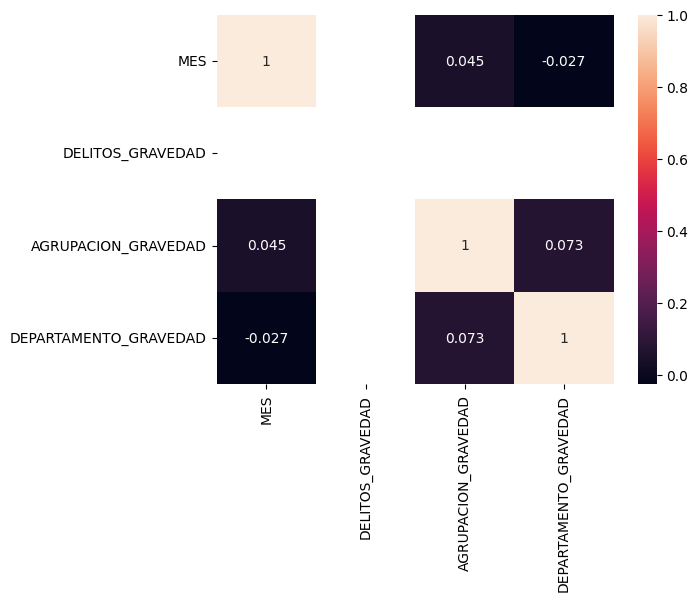

In [ ]:
# Determinamos la correlación entre las variables
sns.heatmap(XD.corr(), annot=True)
plt.show()

La matriz de correlación muestra que las variables seleccionadas no tienen una relación lineal fuerte entre sí, ya que la mayoría de los valores están cercanos a cero. Esto indica que variables como MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD, DEPARTAMENTO_GRAVEDAD y ARMAS_MEDIOS_GRAVEDAD aportan información diferente al análisis.

Aunque la correlación no es alta, estas variables siguen siendo útiles para K-Means, ya que el objetivo del modelo no es predecir una variable específica, sino agrupar registros con características similares dentro de la base de datos.

2. se procede con la implemetancion del modelo K-means


In [ ]:
np.random.seed(42) #son las semillas, permite generar los mismos resultados
NC = 5 # son los 5 grupos o clusters que queremos formar
mkm = KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD) #El modelo agrupa los datos según las variables seleccionadas

#Representa los perfiles encontrados por el modelo
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)


#Para saber a qué grupo pertenece cada registro
ydp = mkm.labels_ #indica en qué cluster quedó clasificado cada dato
NDc = np.bincount(ydp) #número de datos por cluster

print("El número de datos por cluster es:", NDc)

,MES,DELITOS_GRAVEDAD,AGRUPACION_GRAVEDAD,DEPARTAMENTO_GRAVEDAD
0,8.478261,3.0,2.956522,1.391304
1,1.184834,3.0,2.914692,5.364929
2,5.929412,3.0,2.964706,5.105882
3,10.500000,3.0,2.913793,5.189655
4,1.280000,3.0,2.860000,1.540000


El número de datos por cluster es: [ 23 211  85  58  50]


In [ ]:
cluster_labels = mkm.labels_

# Create a DataFrame to combine cluster labels and yd values
cluster_yd_df = pd.DataFrame({'Cluster': cluster_labels, 'yd_value': yd})

# Calculate the count of each yd_value within each cluster
cluster_yd_counts = cluster_yd_df.groupby('Cluster')['yd_value'].value_counts().unstack(fill_value=0)

# Calculate the percentage of each yd_value within each cluster
cluster_yd_percentages = cluster_yd_counts.divide(cluster_yd_counts.sum(axis=1), axis=0) * 100

print("Porcentaje de valores de 'yd' por cluster:")
display(cluster_yd_percentages)

Porcentaje de valores de 'yd' por cluster:


yd_value,0,1
Cluster,,
0,100.000000,0.000000
1,17.535545,82.464455
2,91.764706,8.235294
3,91.379310,8.620690
4,16.000000,84.000000


Se puede observar que el modelo K-Means agrupó los datos en 5 clusters según las variables MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD, DEPARTAMENTO_GRAVEDAD y ARMAS_MEDIOS_GRAVEDAD. Algunos clusters concentraron una mayor cantidad de registros, mostrando que ciertos grupos reúnen gran parte de los casos analizados.

Además, las diferencias más visibles entre los clusters se encuentran principalmente en las variables relacionadas con gravedad y departamento, lo que permitió identificar patrones territoriales y niveles de gravedad similares dentro de la base de datos. Esto demuestra que el modelo logró segmentar correctamente los registros según sus características.


4.¿Qué pasa si aparece un nuevo caso con arma de fuego, en Bogotá, masculino y adulto?

In [ ]:
import warnings
warnings.filterwarnings('ignore')

nuevo_registro = np.array([[1, 0, 1, 1]])

ydp = mkm.predict(nuevo_registro)
NCL = ydp[0]

print("El nuevo registro pertenece al cluster:", ydp)
print("Las características del cluster son:")
display(Tabla.iloc[[NCL]])

El nuevo registro pertenece al cluster: [4]
Las características del cluster son:


,MES,DELITOS_GRAVEDAD,AGRUPACION_GRAVEDAD,DEPARTAMENTO_GRAVEDAD
4,1.28,3.0,2.86,1.54


Al ingresar un nuevo registro con características asociadas a las variables utilizadas en el modelo, el algoritmo K-Means lo clasificó dentro de uno de los clusters generados. Este resultado indica que el nuevo caso presenta similitudes con los registros agrupados en ese cluster.

Según las características promedio del grupo, el modelo identifica patrones relacionados con niveles de gravedad, ubicación y agrupación poblacional, permitiendo asociar el nuevo registro con un perfil similar dentro de la base de datos analizada.


5. Gráfica de los clusters utilizando las variables ARMAS MEDIOS y DEPARTAMENTO

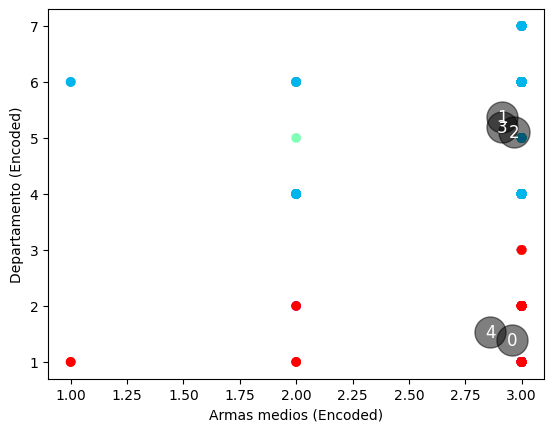

In [ ]:
centers = mkm.cluster_centers_   # centroides

# Use the numerically encoded data for plotting
arm = np.array(XD.iloc[:,2]) # Use encoded 'ARMAS MEDIOS'
dep = np.array(XD.iloc[:,3]) # Use encoded 'DEPARTAMENTO'

plt.figure()
plt.scatter(arm, dep, c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,2], centers[:,3], c='black', s=500, alpha=0.5)
plt.xlabel("Armas medios (Encoded)") # Update label for clarity
plt.ylabel("Departamento (Encoded)") # Update label for clarity

# poner los numeros a los cluster correspondientes
for i, center in enumerate(centers):
    plt.text(center[2], center[3], str(i), color='white',
             fontsize=12, ha='center', va='center')

plt.show()

En la gráfica se observa cómo el modelo K-Means agrupó los datos según las variables relacionadas con gravedad y departamento. Cada color representa un cluster diferente y los círculos negros muestran el centro de cada grupo.

Los grupos presentan diferencias principalmente en las variables relacionadas con el departamento y los niveles de gravedad, permitiendo identificar patrones similares entre los registros analizados. Además, algunos clusters concentran una mayor cantidad de datos, mostrando tendencias comunes dentro de la base utilizada.

La gráfica no se observa tan ordenada porque las variables utilizadas corresponden a datos categóricos codificados y no a variables numéricas continuas con muchos valores diferentes.


**Ánalisis de trabajo**

En conclusión, el árbol de decisión permitió identificar cómo las variables MES, DELITOS_GRAVEDAD, AGRUPACION_GRAVEDAD y DEPARTAMENTO_GRAVEDAD se relacionan para clasificar los registros analizados. El modelo mostró que variables como el departamento y la gravedad tuvieron un peso importante dentro de la clasificación, ya que aparecen varias veces como criterios de separación en el árbol.

Por otro lado, el modelo K-Means permitió agrupar los registros en diferentes clusters según características similares. A diferencia del árbol de decisión, este modelo no busca predecir una categoría específica, sino identificar patrones y agrupamientos dentro de la información analizada.

De manera general, el trabajo permitió analizar la base de datos desde dos enfoques diferentes: uno de clasificación y otro de agrupamiento. Esto ayudó a comprender mejor cómo se relacionan variables como gravedad, ubicación y agrupación poblacional dentro de los registros analizados. Aunque las variables utilizadas son categóricas y no numéricas continuas, los modelos permitieron identificar tendencias y patrones importantes para apoyar el análisis y la toma de decisiones.

In [ ]:
print(XDB['DELITOS'].unique())

['ARTÍCULO 111. LESIONES PERSONALES'
 'ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR'
 'ARTÍCULO 205. ACCESO CARNAL VIOLENTO'
 'ARTÍCULO 206. ACTO SEXUAL VIOLENTO'
 'ARTÍCULO 208. ACCESO CARNAL ABUSIVO CON MENOR DE 14 AÑOS'
 'ARTÍCULO 103. HOMICIDIO' 'ARTÍCULO 104A. FEMINICIDIO'
 'ARTÍCULO 239. HURTO PERSONAS' 'ARTÍCULO 239. HURTO RESIDENCIAS'
 'ARTÍCULO 239. HURTO PIRATERÍA TERRESTRE' 'ARTÍCULO 243. ABIGEATO'
 'ARTÍCULO 168. SECUESTRO SIMPLE' 'ARTÍCULO 169. SECUESTRO EXTORSIVO'
 'ARTÍCULO 347. AMENAZAS' 'ARTÍCULO 239. HURTO MOTOCICLETAS'
 'ARTÍCULO 239. HURTO AUTOMOTORES']


In [ ]:
# Define un diccionario para mapear cada delito a un valor de gravedad (1-11)
# Por favor, ajusta los valores numéricos según tu criterio.
delitos_gravedad_map = {
    'ARTÍCULO 111. LESIONES PERSONALES': 3, # Ejemplo: Ajusta este valor
    'ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR': 5, # Ejemplo: Ajusta este valor
    'ARTÍCULO 205. ACCESO CARNAL VIOLENTO': 9, # Ejemplo: Ajusta este valor
    'ARTÍCULO 206. ACTO SEXUAL VIOLENTO': 8, # Ejemplo: Ajusta este valor
    'ARTÍCULO 208. ACCESO CARNAL ABUSIVO CON MENOR DE 14 AÑOS': 10, # Ejemplo: Ajusta este valor
    'ARTÍCULO 103. HOMICIDIO': 11, # Ejemplo: Ajusta este valor
    'ARTÍCULO 104A. FEMINICIDIO': 11, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO PERSONAS': 4, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO RESIDENCIAS': 6, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO PIRATERÍA TERRESTRE': 7, # Ejemplo: Ajusta este valor
    'ARTÍCULO 243. ABIGEATO': 2, # Ejemplo: Ajusta este valor
    'ARTÍCULO 168. SECUESTRO SIMPLE': 9, # Ejemplo: Ajusta este valor
    'ARTÍCULO 169. SECUESTRO EXTORSIVO': 10, # Ejemplo: Ajusta este valor
    'ARTÍCULO 347. AMENAZAS': 1, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO MOTOCICLETAS': 4, # Ejemplo: Ajusta este valor
    'ARTÍCULO 239. HURTO AUTOMOTORES': 5  # Ejemplo: Ajusta este valor
}

# Crea una nueva columna 'DELITOS_GRAVEDAD' mapeando los valores existentes
XDB['DELITOS_GRAVEDAD'] = XDB['DELITOS'].map(delitos_gravedad_map)

# Muestra las primeras filas del DataFrame con la nueva columna
display(XDB[['DELITOS', 'DELITOS_GRAVEDAD']].head())

,DELITOS,DELITOS_GRAVEDAD
0,ARTÍCULO 111. LESIONES PERSONALES,3
1,ARTÍCULO 111. LESIONES PERSONALES,3
2,ARTÍCULO 111. LESIONES PERSONALES,3
3,ARTÍCULO 111. LESIONES PERSONALES,3
4,ARTÍCULO 111. LESIONES PERSONALES,3


In [ ]:
# Mapeo para 'ARMAS MEDIOS'
print("Valores únicos en 'ARMAS MEDIOS':", XDB['ARMAS MEDIOS'].unique())
armas_medios_gravedad_map = {
    'ARMA DE FUEGO': 5, # Ajusta este valor
    'ARMA BLANCA / CORTOPUNZANTE': 3, # Ajusta este valor
    'ARMA TRAUMÁTICA': 2, # Ajusta este valor
    'SIN EMPLEO DE ARMAS': 1, # Ajusta este valor
    'ÁCIDO': 4, # Ajusta este valor
    'CUALES': 1, # Ajusta este valor
    'CONTUNDENTES': 2 # Ajusta este valor
}
XDB['ARMAS_MEDIOS_GRAVEDAD'] = XDB['ARMAS MEDIOS'].map(armas_medios_gravedad_map)
display(XDB[['ARMAS MEDIOS', 'ARMAS_MEDIOS_GRAVEDAD']].head())

Valores únicos en 'ARMAS MEDIOS': ['ARMA DE FUEGO' 'ARMA TRAUMATICA' 'ACIDO']


,ARMAS MEDIOS,ARMAS_MEDIOS_GRAVEDAD
0,ARMA DE FUEGO,5.0
1,ARMA DE FUEGO,5.0
2,ARMA DE FUEGO,5.0
3,ARMA DE FUEGO,5.0
4,ARMA DE FUEGO,5.0


In [ ]:
# Mapeo para 'GENERO'
print("Valores únicos en 'GENERO':", XDB['GENERO'].unique())
genero_gravedad_map = {
    'MASCULINO': 1, # Ajusta este valor
    'FEMENINO': 1, # Ajusta este valor
    'LGBTI': 1 # Ajusta este valor
}
XDB['GENERO_GRAVEDAD'] = XDB['GENERO'].map(genero_gravedad_map)
display(XDB[['GENERO', 'GENERO_GRAVEDAD']].head())

Valores únicos en 'GENERO': ['MASCULINO' 'FEMENINO']


,GENERO,GENERO_GRAVEDAD
0,MASCULINO,1
1,MASCULINO,1
2,MASCULINO,1
3,MASCULINO,1
4,MASCULINO,1


In [ ]:
# Mapeo para 'AGRUPACION'
print("Valores únicos en 'AGRUPACION':", XDB['AGRUPACION'].unique())
agrupacion_gravedad_map = {
    'ADULTOS': 2, # Ajusta este valor
    'ADOLESCENTES': 1, # Ajusta este valor
    'MENORES': 1 # Ajusta este valor
}
XDB['AGRUPACION_GRAVEDAD'] = XDB['AGRUPACION'].map(agrupacion_gravedad_map)
display(XDB[['AGRUPACION', 'AGRUPACION_GRAVEDAD']].head())

Valores únicos en 'AGRUPACION': ['ADULTOS' 'MENORES' 'ADOLESCENTES']


,AGRUPACION,AGRUPACION_GRAVEDAD
0,ADULTOS,2
1,ADULTOS,2
2,ADULTOS,2
3,ADULTOS,2
4,ADULTOS,2


In [ ]:
# Mapeo para 'MES'
print("Valores únicos en 'MES':", XDB['MES'].unique())
mes_gravedad_map = {
    1.0: 1, 2.0: 1, 3.0: 1, 4.0: 1, 5.0: 1, 6.0: 1, # Ajusta estos valores
    7.0: 1, 8.0: 1, 9.0: 1, 10.0: 1, 11.0: 1, 12.0: 1 # Ajusta estos valores
}
XDB['MES_GRAVEDAD'] = XDB['MES'].map(mes_gravedad_map)
display(XDB[['MES', 'MES_GRAVEDAD']].head())

Valores únicos en 'MES': [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]


,MES,MES_GRAVEDAD
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
